# Live/Dead Cell Classification — Analysis

## Part 1: Data Exploration

In [1]:
import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
from PIL import Image

sns.set_theme(style="whitegrid")

DATA_ROOT = Path(os.getenv("DATA_ROOT", ".")).resolve()
df = pd.read_csv(DATA_ROOT / "images" / "metadata.csv")

print(f"DATA_ROOT: {DATA_ROOT}")
print(f"Shape: {df.shape}")
print(f"\nNull counts:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
df.head()

DATA_ROOT: /home/itield7/TeraCyte_assignment
Shape: (10827, 18)

Null counts:
Series([], dtype: int64)


,sample_id,exp_id,assay_id,assay_index,global_index,label,magnification,channel_name,sequence,z_plane,well_diameter_um,x_fov,y_fov,r_fov,x,y,r,filepath
0,5738_0000_004079,exp-20260310120827-5738,assay-20260310120944-3366,0,4079,live,4.0,BF,0,0,30.0,3465.0,521.0,21.0,112.0,112.0,52.266667,images/5738_0000_004079.png
1,5738_0000_004091,exp-20260310120827-5738,assay-20260310120944-3366,0,4091,dead,4.0,BF,0,0,30.0,3318.0,572.0,21.0,112.0,112.0,52.266667,images/5738_0000_004091.png
2,5738_0000_004094,exp-20260310120827-5738,assay-20260310120944-3366,0,4094,dead,4.0,BF,0,0,30.0,3494.0,572.0,21.0,112.0,112.0,52.266667,images/5738_0000_004094.png
3,5738_0000_004104,exp-20260310120827-5738,assay-20260310120944-3366,0,4104,live,4.0,BF,0,0,30.0,4080.0,571.0,21.0,112.0,112.0,52.266667,images/5738_0000_004104.png
4,5738_0000_004110,exp-20260310120827-5738,assay-20260310120944-3366,0,4110,dead,4.0,BF,0,0,30.0,3582.0,623.0,21.0,112.0,112.0,52.266667,images/5738_0000_004110.png


### Experiments and assays

The dataset contains **two imaging experiments**. Each experiment has **two assays** (four assays total).

In [2]:
exp_summary = (
    df.groupby(["exp_id", "assay_id"])
    .size()
    .reset_index(name="n_samples")
    .sort_values(["exp_id", "assay_id"])
)
exp_summary["exp_short"] = exp_summary["exp_id"].str.split("-").str[-1]
exp_summary["assay_short"] = exp_summary["assay_id"].str.split("-").str[-1]

for exp_id, group in exp_summary.groupby("exp_id"):
    exp_short = exp_id.split("-")[-1]
    print(f"Experiment {exp_short} ({exp_id}): {group['n_samples'].sum():,} samples total")
    for _, row in group.iterrows():
        print(f"  assay {row.assay_short}: {row.n_samples:,} samples")
    print()

print(f"Grand total: {len(df):,} samples across {df['exp_id'].nunique()} experiments and {df['assay_id'].nunique()} assays")
display(exp_summary[["exp_short", "assay_short", "n_samples"]])

Experiment 9996 (exp-20260204102540-9996): 8,923 samples total
  assay 0469: 1,036 samples
  assay 9793: 7,887 samples

Experiment 5738 (exp-20260310120827-5738): 1,904 samples total
  assay 3366: 823 samples
  assay 7091: 1,081 samples

Grand total: 10,827 samples across 2 experiments and 4 assays


,exp_short,assay_short,n_samples
0,9996,0469,1036
1,9996,9793,7887
2,5738,3366,823
3,5738,7091,1081


### Live/dead distribution — all samples

Overall class balance across the full dataset.

live: 8,200 (75.7%)
dead: 2,627 (24.3%)


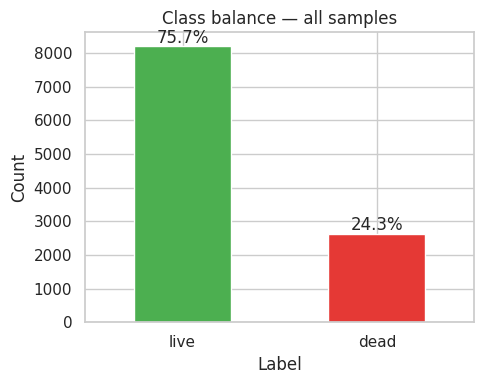

In [3]:
counts = df["label"].value_counts()
pcts = df["label"].value_counts(normalize=True) * 100
for label in counts.index:
    print(f"{label}: {counts[label]:,} ({pcts[label]:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 4))
counts.plot(kind="bar", ax=ax, color=["#4CAF50", "#E53935"])
ax.set_xlabel("Label")
ax.set_ylabel("Count")
ax.set_title("Class balance — all samples")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
for i, v in enumerate(counts.values):
    ax.text(i, v + 100, f"{pcts.iloc[i]:.1f}%", ha="center")
plt.tight_layout()
plt.show()

### Live/dead distribution — by experiment and assay

Per experiment:


label,dead,live,pct_dead
exp_id,,,
exp-20260204102540-9996,1923,7000,21.6
exp-20260310120827-5738,704,1200,37.0



Per assay:


label                                              dead  live  pct_dead
exp_id                  assay_id                                       
exp-20260204102540-9996 assay-20260204103236-0469   234   802      22.6
                        assay-20260204103330-9793  1689  6198      21.4
exp-20260310120827-5738 assay-20260310120944-3366   407   416      49.5
                        assay-20260310120948-7091   297   784      27.5

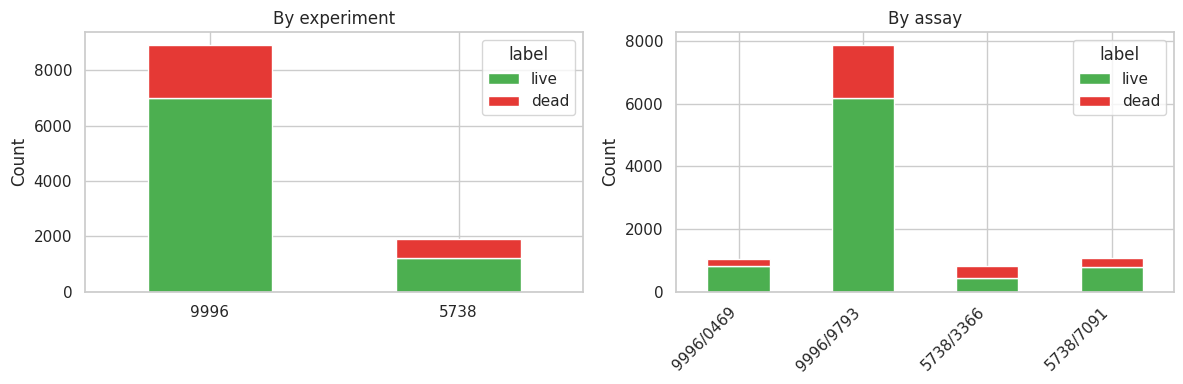

In [4]:
by_exp = df.groupby(["exp_id", "label"]).size().unstack(fill_value=0)
by_exp["pct_dead"] = (by_exp["dead"] / (by_exp["live"] + by_exp["dead"]) * 100).round(1)
print("Per experiment:")
display(by_exp)

by_assay = df.groupby(["exp_id", "assay_id", "label"]).size().unstack(fill_value=0)
by_assay["pct_dead"] = (by_assay["dead"] / (by_assay["live"] + by_assay["dead"]) * 100).round(1)
print("\nPer assay:")
display(by_assay)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

by_exp[["live", "dead"]].plot(kind="bar", stacked=True, ax=axes[0], color=["#4CAF50", "#E53935"])
axes[0].set_title("By experiment")
axes[0].set_xlabel("")
axes[0].set_ylabel("Count")
axes[0].set_xticklabels([e.split("-")[-1] for e in by_exp.index], rotation=0)
axes[0].legend(title="label")

by_assay[["live", "dead"]].plot(kind="bar", stacked=True, ax=axes[1], color=["#4CAF50", "#E53935"])
axes[1].set_title("By assay")
axes[1].set_xlabel("")
axes[1].set_ylabel("Count")
axes[1].set_xticklabels([f"{e.split('-')[-1]}/{a.split('-')[-1]}" for e, a in by_assay.index], rotation=45, ha="right")
axes[1].legend(title="label")

plt.tight_layout()
plt.show()

### r_fov

Two well sizes: `r_fov=21` and `r_fov=36`. Pixels outside the well circle are background value 231.
We confirm all images are 224×224 and that the declared radius `r` is ~52.27 (r_fov=21) and ~89.60 (r_fov=36), with all pixels beyond `r` equal to 231.

In [5]:
print("r_fov counts:")
print(df["r_fov"].value_counts().sort_index())

print("\nr_fov x label:")
display(pd.crosstab(df["r_fov"], df["label"]))

print("\nr_fov x assay:")
display(df.groupby(["r_fov", "assay_id"]).size().unstack(fill_value=0))

# --- image shape and circle radius ---
BG = 231

shape_check = df.sample(min(200, len(df)), random_state=42)
shapes = {Image.open(DATA_ROOT / "images" / row.filepath).size for _, row in shape_check.iterrows()}
print(f"\nImage shapes (sample of {len(shape_check)}): {shapes}")

print("\nDeclared radius r in metadata:")
display(df.groupby("r_fov")["r"].agg(["mean", "min", "max"]).round(2))

radius_check = df.groupby("r_fov", group_keys=False).apply(
    lambda g: g.sample(min(100, len(g)), random_state=42)
)
rows = []
for _, row in radius_check.iterrows():
    img = np.array(Image.open(DATA_ROOT / "images" / row.filepath))
    yy, xx = np.ogrid[:224, :224]
    dist = np.sqrt((xx - row.x) ** 2 + (yy - row.y) ** 2)
    outside = dist > row.r
    rows.append({
        "r_fov": row.r_fov,
        "r_metadata": row.r,
        "outside_all_231": (img[outside] == BG).all(),
        "n_outside": outside.sum(),
    })
radius_df = pd.DataFrame(rows)

print("\nConfirm circle boundary: all pixels beyond r are background (231):")
display(radius_df.groupby("r_fov").agg(
    r=("r_metadata", "mean"),
    outside_all_231=("outside_all_231", "all"),
    n_outside=("n_outside", "mean"),
).round(2))

print("\nExpected: r_fov=21 → r ≈ 52.27, r_fov=36 → r ≈ 89.60, all images 224×224")

r_fov counts:
r_fov
21.0    9791
36.0    1036
Name: count, dtype: int64

r_fov x label:


label,dead,live
r_fov,,
21.0,2393,7398
36.0,234,802



r_fov x assay:


assay_id,assay-20260204103236-0469,assay-20260204103330-9793,assay-20260310120944-3366,assay-20260310120948-7091
r_fov,,,,
21.0,0,7887,823,1081
36.0,1036,0,0,0



Image shapes (sample of 200): {(224, 224)}

Declared radius r in metadata:


,mean,min,max
r_fov,,,
21.0,52.27,52.27,52.27
36.0,89.60,89.60,89.60


/tmp/ipykernel_16936/1186552024.py:20: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  radius_check = df.groupby("r_fov", group_keys=False).apply(



Confirm circle boundary: all pixels beyond r are background (231):


,r,outside_all_231,n_outside
r_fov,,,
21.0,52.27,False,41591.0
36.0,89.60,False,24943.0



Expected: r_fov=21 → r ≈ 52.27, r_fov=36 → r ≈ 89.60, all images 224×224


### Image examples

Live vs dead cells from each assay, and a comparison of `r_fov=21` vs `r_fov=36`.

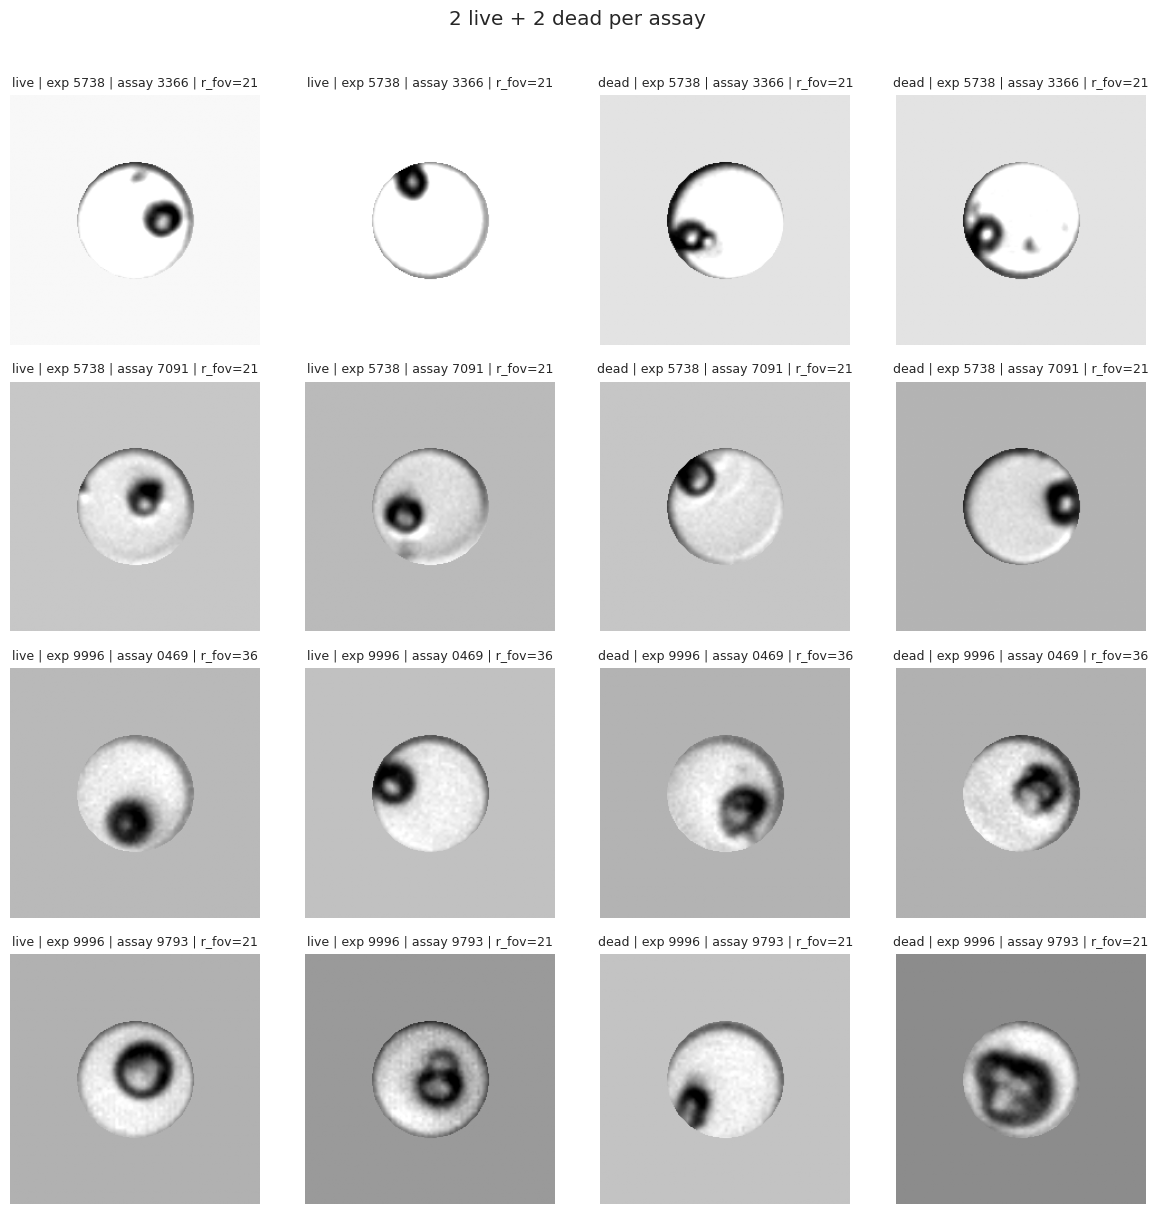

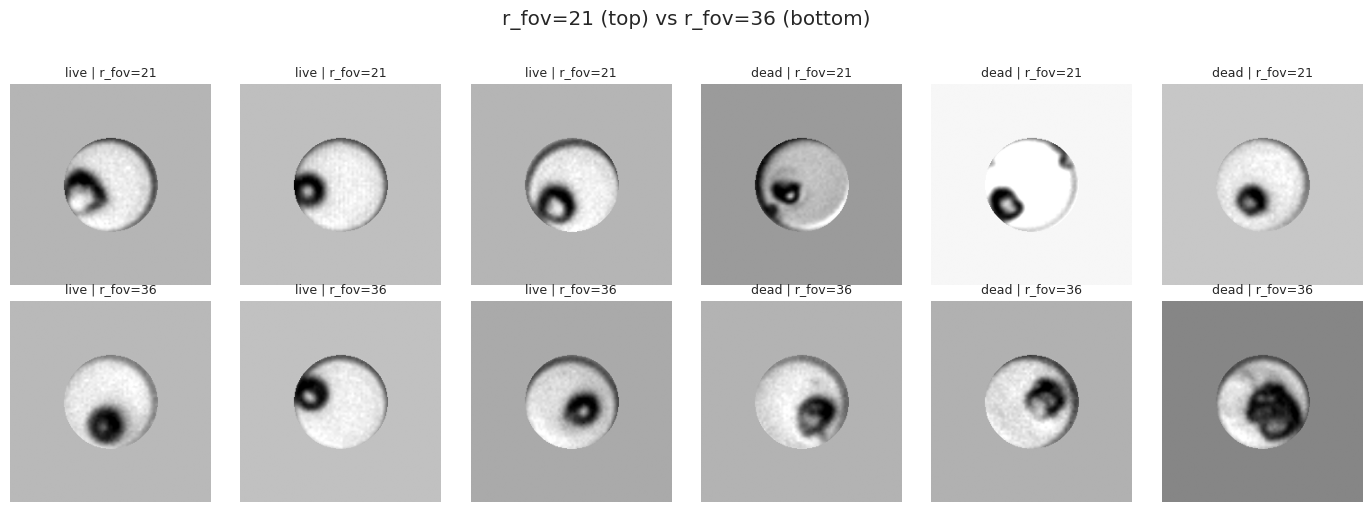

In [6]:
assays = df["assay_id"].unique()
samples = []
for assay in assays:
    subset = df[df["assay_id"] == assay]
    samples.append(subset[subset["label"] == "live"].sample(2, random_state=42))
    samples.append(subset[subset["label"] == "dead"].sample(2, random_state=42))
gallery = pd.concat(samples)

fig, axes = plt.subplots(4, 4, figsize=(12, 12))
for ax, (_, row) in zip(axes.flat, gallery.iterrows()):
    img = Image.open(DATA_ROOT / "images" / row.filepath)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"{row.label} | exp {row.exp_id[-4:]} | assay {row.assay_id[-4:]} | r_fov={int(row.r_fov)}", fontsize=9)
    ax.axis("off")
plt.suptitle("2 live + 2 dead per assay", y=1.01)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for col, label in enumerate(["live", "dead"]):
    for row_idx, r_fov in enumerate([21, 36]):
        subset = df[(df["r_fov"] == r_fov) & (df["label"] == label)].sample(3, random_state=42)
        for i, (_, sample) in enumerate(subset.iterrows()):
            ax = axes[row_idx, col * 3 + i]
            img = Image.open(DATA_ROOT / "images" / sample.filepath)
            ax.imshow(img, cmap="gray")
            ax.set_title(f"{label} | r_fov={int(r_fov)}", fontsize=9)
            ax.axis("off")
plt.suptitle("r_fov=21 (top) vs r_fov=36 (bottom)", y=1.02)
plt.tight_layout()
plt.show()

### Image quality

Metrics computed on the full dataset. Outliers (IQR method) are saved to `quality_outliers.csv`.

Computing quality metrics on full dataset...


Summary statistics:


,mean_intensity,std_intensity,dynamic_range,well_mean,well_std,pct_zero,sharpness
count,10827.00,10827.00,10827.00,10827.00,10827.00,10827.00,10827.00
mean,181.91,27.21,249.04,181.78,27.20,0.26,151.83
std,28.48,4.03,31.96,28.46,4.35,0.64,95.74
min,4.51,2.42,14.00,4.51,2.42,0.00,0.49
25%,175.06,26.48,255.00,174.93,26.42,0.18,90.97
50%,182.94,27.92,255.00,182.80,27.85,0.19,132.45
75%,189.08,29.10,255.00,188.98,29.02,0.20,186.24
max,251.22,38.38,255.00,251.23,78.15,5.75,725.10


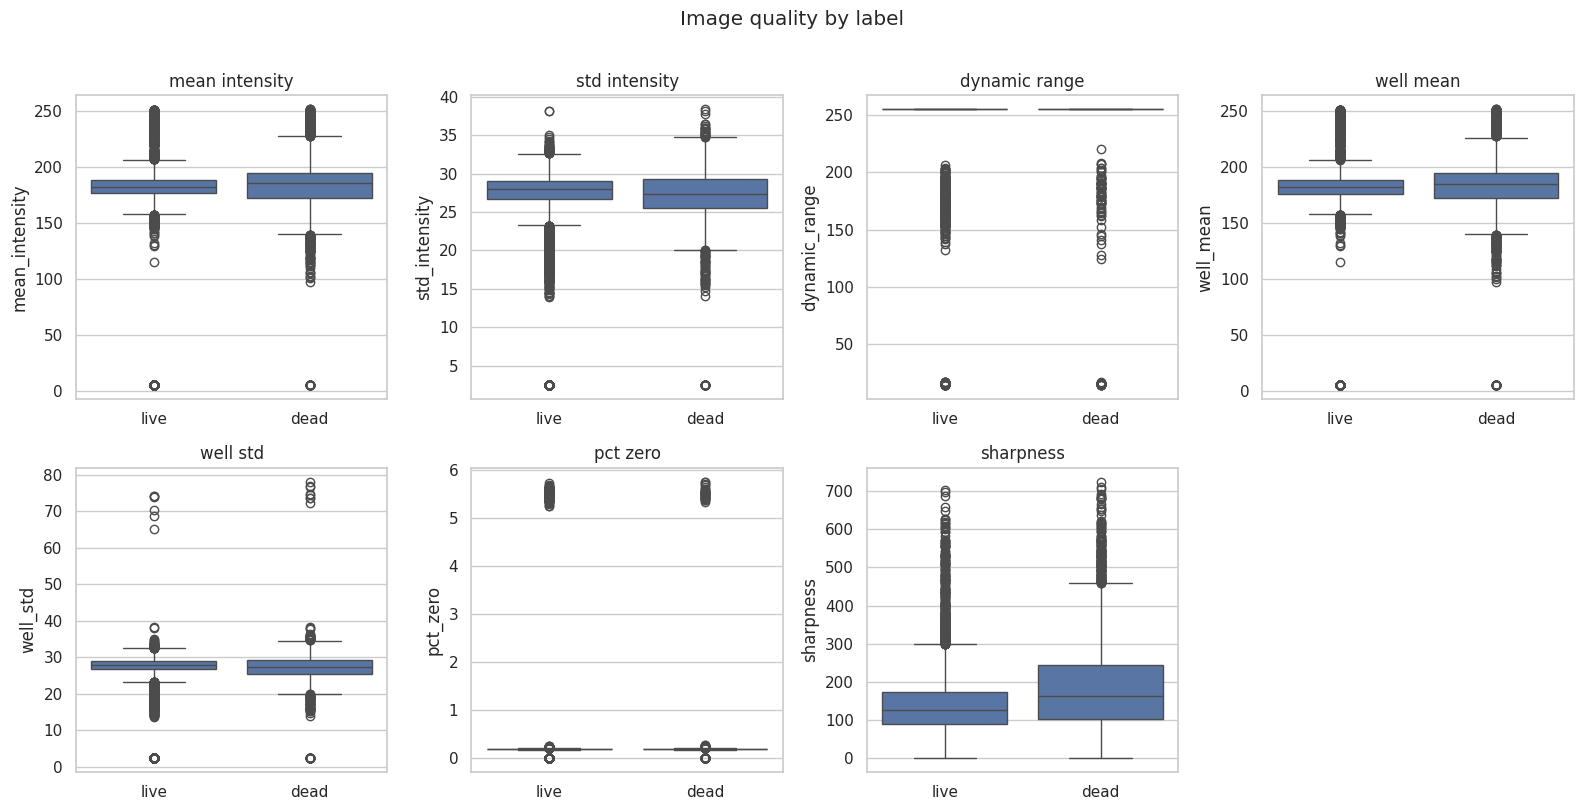


Outliers saved to /home/itield7/TeraCyte_assignment/quality_outliers.csv
Total outlier samples: 2,023 / 10,827
  single-category: 312
  multi-category:  1,711

Outliers per metric:
  mean_intensity: 1,176
  std_intensity: 764
  dynamic_range: 487
  well_mean: 1,162
  well_std: 787
  pct_zero: 666
  sharpness: 565


In [7]:
BG = 231
METRICS = [
    "mean_intensity", "std_intensity", "dynamic_range",
    "well_mean", "well_std", "pct_zero", "sharpness",
]

def image_metrics(filepath):
    img = np.array(Image.open(DATA_ROOT / "images" / filepath), dtype=np.float64)
    well = img[img != BG]
    laplacian = (
        -4 * img[1:-1, 1:-1]
        + img[:-2, 1:-1] + img[2:, 1:-1]
        + img[1:-1, :-2] + img[1:-1, 2:]
    )
    return {
        "mean_intensity": img.mean(),
        "std_intensity": img.std(),
        "dynamic_range": img.max() - img.min(),
        "well_mean": well.mean() if len(well) else 0,
        "well_std": well.std() if len(well) else 0,
        "pct_zero": (img == 0).mean() * 100,
        "sharpness": laplacian.var(),
    }

print("Computing quality metrics on full dataset...")
quality = df[["sample_id", "filepath", "label", "exp_id"]].copy()
metrics_df = pd.DataFrame(quality["filepath"].apply(image_metrics).tolist())
quality = pd.concat([quality.reset_index(drop=True), metrics_df], axis=1)

print("Summary statistics:")
display(quality[METRICS].describe().round(2))

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
for ax, metric in zip(axes.flat, METRICS):
    sns.boxplot(data=quality, x="label", y=metric, ax=ax)
    ax.set_title(metric.replace("_", " "))
    ax.set_xlabel("")
axes.flat[-1].axis("off")
plt.suptitle("Image quality by label", y=1.01)
plt.tight_layout()
plt.show()

# --- outlier detection (IQR) ---
def iqr_outlier_mask(series, k=1.5):
    q1, q3 = series.quantile([0.25, 0.75])
    iqr = q3 - q1
    return (series < q1 - k * iqr) | (series > q3 + k * iqr)

outlier_flags = {}
for metric in METRICS:
    col = f"outlier_{metric}"
    quality[col] = iqr_outlier_mask(quality[metric])
    outlier_flags[metric] = col

outlier_cols = list(outlier_flags.values())
quality["n_outlier_metrics"] = quality[outlier_cols].sum(axis=1)
quality["outlier_in"] = quality.apply(
    lambda r: ",".join(m for m in METRICS if r[f"outlier_{m}"]), axis=1
)

outliers = quality[quality["n_outlier_metrics"] > 0].copy()
outliers.to_csv(DATA_ROOT / "quality_outliers.csv", index=False)

print(f"\nOutliers saved to {DATA_ROOT / 'quality_outliers.csv'}")
print(f"Total outlier samples: {len(outliers):,} / {len(quality):,}")
print(f"  single-category: {(outliers['n_outlier_metrics'] == 1).sum():,}")
print(f"  multi-category:  {(outliers['n_outlier_metrics'] > 1).sum():,}")
print("\nOutliers per metric:")
for metric in METRICS:
    print(f"  {metric}: {quality[f'outlier_{metric}'].sum():,}")

### Quality outlier examples

Single-category outliers (flagged in exactly one metric) and multi-category outliers (flagged in two or more).

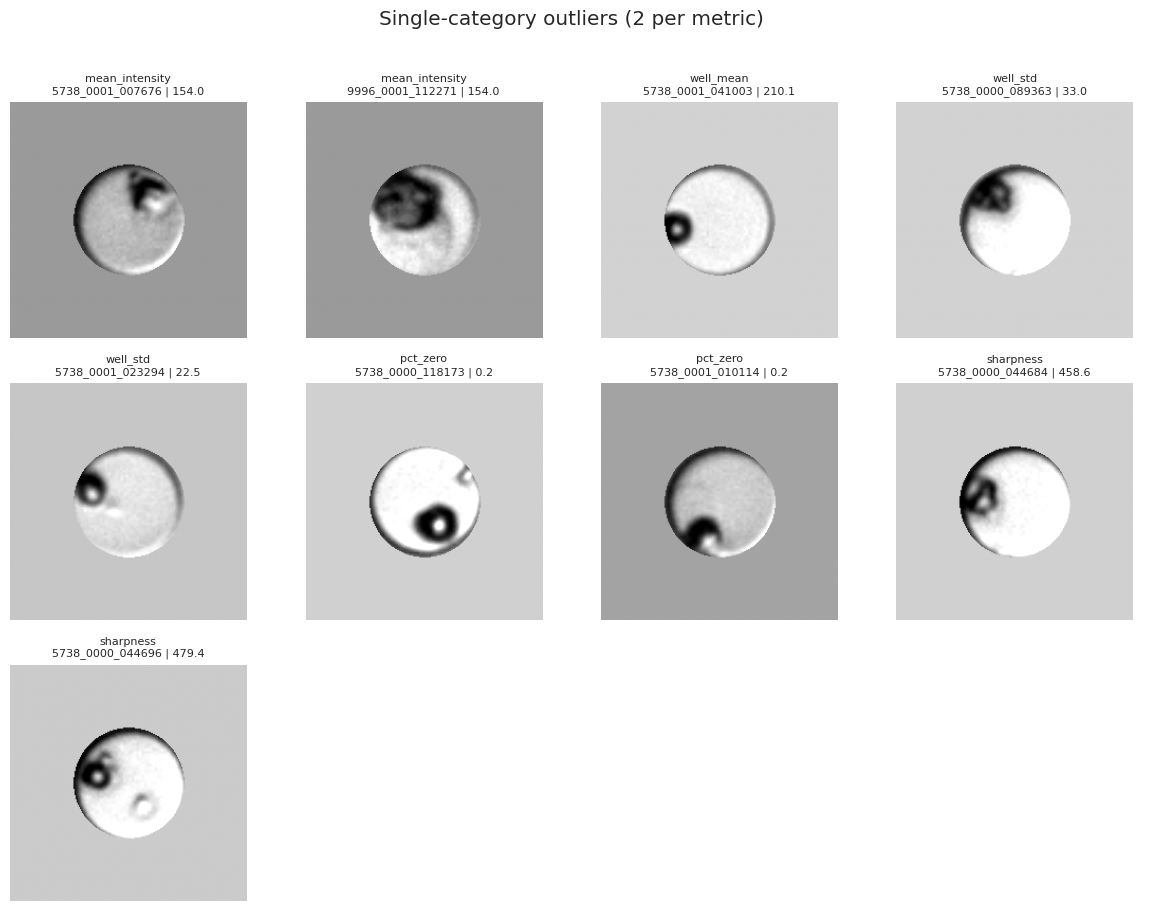

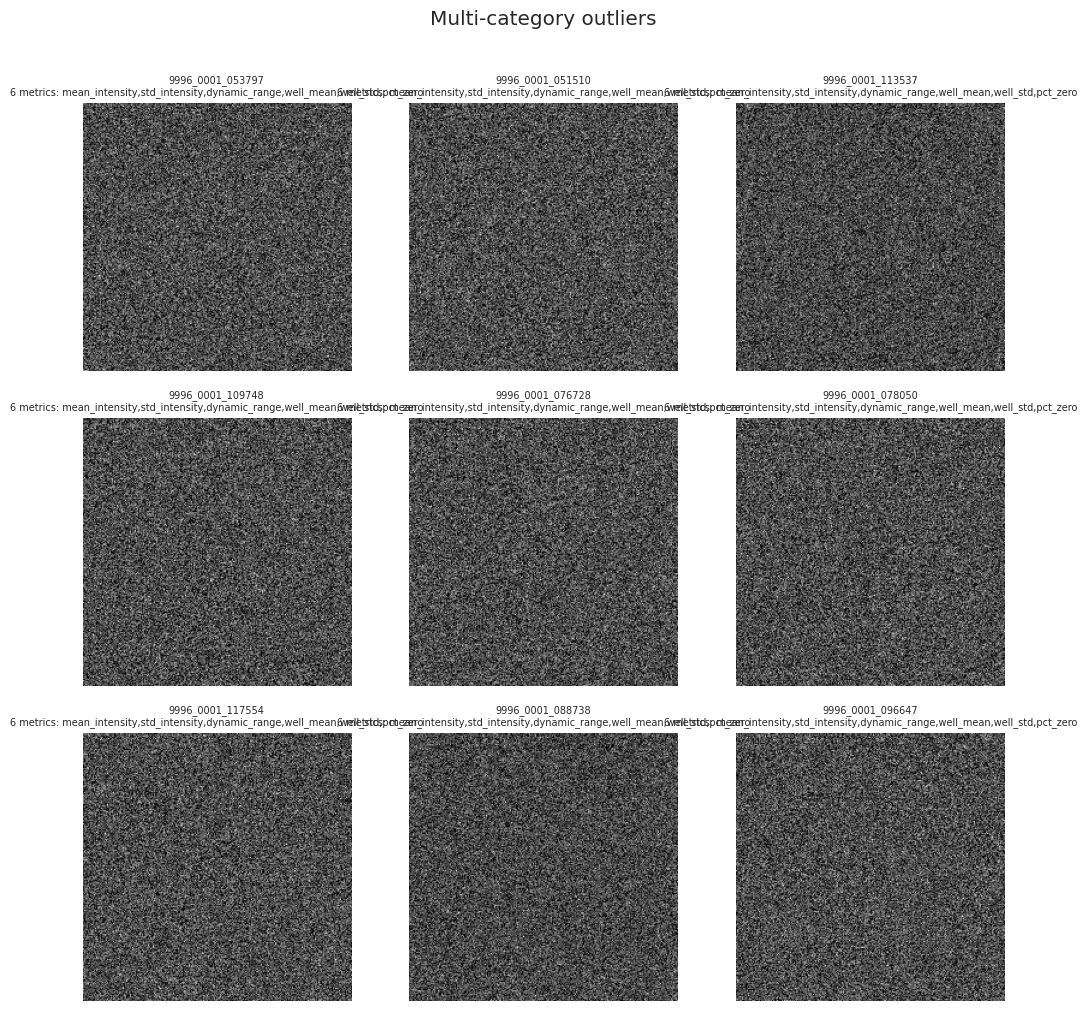

In [8]:
single = outliers[outliers["n_outlier_metrics"] == 1]

# --- single-category outliers: 2 examples per metric ---
examples_per_metric = []
for metric in METRICS:
    col = f"outlier_{metric}"
    subset = single[single[col]].head(2)
    for _, row in subset.iterrows():
        examples_per_metric.append((metric, row))

n = len(examples_per_metric)
cols = 4
rows = int(np.ceil(n / cols))
fig, axes = plt.subplots(rows, cols, figsize=(3 * cols, 3 * rows))
for ax, (metric, row) in zip(axes.flat, examples_per_metric):
    img = Image.open(DATA_ROOT / "images" / row.filepath)
    ax.imshow(img, cmap="gray")
    val = row[metric]
    ax.set_title(f"{metric}\n{row.sample_id} | {val:.1f}", fontsize=8)
    ax.axis("off")
for ax in axes.flat[n:]:
    ax.axis("off")
plt.suptitle("Single-category outliers (2 per metric)", y=1.01)
plt.tight_layout()
plt.show()

# --- multi-category outliers ---
multi = outliers[outliers["n_outlier_metrics"] > 1].sort_values("n_outlier_metrics", ascending=False).head(9)

fig, axes = plt.subplots(3, 3, figsize=(10, 10))
for ax, (_, row) in zip(axes.flat, multi.iterrows()):
    img = Image.open(DATA_ROOT / "images" / row.filepath)
    ax.imshow(img, cmap="gray")
    ax.set_title(f"{row.sample_id}\n{row.n_outlier_metrics} metrics: {row.outlier_in}", fontsize=7)
    ax.axis("off")
for ax in axes.flat[len(multi):]:
    ax.axis("off")
plt.suptitle("Multi-category outliers", y=1.01)
plt.tight_layout()
plt.show()

### Observations

- **Two experiments, four assays**: exp 5738 (1,904 samples, 2 assays) and exp 9996 (8,923 samples, 2 assays).
- **Class imbalance**: ~76% live / ~24% dead overall; models will need to account for this.
- **Dead rate varies by assay**: ranges from ~23% to ~43%, so batch effects matter.
- **Circular mask is consistent**: all images are 224×224; effective radius from pixels ≠ 231 matches metadata `r` (~52.27 for r_fov=21, ~89.6 for r_fov=36).
- **r_fov=36**: one assay uses larger wells that fill more of the 224 px crop — a potential domain shift.
- **Brightness, contrast, and sharpness differ between experiments**, suggesting batch effects in exposure or focus.
- **Quality outliers**: saved to `quality_outliers.csv`; single-metric flags often reflect brightness or focus extremes, multi-metric flags suggest broadly low-quality acquisitions.
- **Subtle BF signal**: live vs dead is not always obvious by eye; classification will rely on fine-grained texture differences.

---

## Part 2: Data Cleaning and Split

### Data cleaning

Samples flagged as outliers in **4 or more** of the 7 quality metrics are labelled `noisy` and excluded from train/val/test. They are tracked in the split as `noisy` so they can be analysed later.

In [9]:
NOISY_THRESHOLD = 4

outliers_df = pd.read_csv(DATA_ROOT / "quality_outliers.csv")
noisy_ids = set(outliers_df.loc[outliers_df["n_outlier_metrics"] >= NOISY_THRESHOLD, "sample_id"])

df_clean = df[~df["sample_id"].isin(noisy_ids)].copy()
df_noisy = df[df["sample_id"].isin(noisy_ids)].copy()

print(f"Total samples:  {len(df):,}")
print(f"Noisy (≥{NOISY_THRESHOLD} flags): {len(df_noisy):,} ({100*len(df_noisy)/len(df):.1f}%)")
print(f"Clean:          {len(df_clean):,}")
print(f"\nNoisy by label:\n{df_noisy['label'].value_counts()}")
print(f"\nNoisy by assay:\n{df_noisy.groupby('assay_id').size()}")

Total samples:  10,827
Noisy (≥4 flags): 559 (5.2%)
Clean:          10,268

Noisy by label:
label
live    395
dead    164
Name: count, dtype: int64

Noisy by assay:
assay_id
assay-20260204103236-0469     58
assay-20260204103330-9793    466
assay-20260310120944-3366     32
assay-20260310120948-7091      3
dtype: int64


### Train / val / test split

We keep **all** clean samples and handle the class imbalance during training with a **weighted loss** (plus normalization and augmentation). No data is discarded or subset to force balance.

**Strategy:**

- Stratify by `(assay_id, label)` — 8 groups — and split each group 70 / 15 / 15.
- This preserves the natural class ratio *and* the assay / r_fov distribution identically across train, val, and test.
- `noisy` samples (≥4 outlier flags) get their own split label and are excluded from modelling.

**Why val/test stay imbalanced:**  
Validation and test should mirror the real deployment distribution, so they keep the natural ~79/21 live/dead ratio. Imbalance is corrected only in the *training* loss. We therefore evaluate with imbalance-robust metrics (per-class recall, F1, balanced accuracy, PR-AUC) rather than raw accuracy, and report them **per assay** to surface batch-specific behaviour.

In [10]:
VAL_FRAC  = 0.15
TEST_FRAC = 0.15
SEED = 42

def assign_splits(sample_ids):
    """Shuffle ids and split into train/val/test by fraction."""
    ids = list(sample_ids)
    rng = np.random.default_rng(SEED)
    rng.shuffle(ids)
    n = len(ids)
    n_test = max(1, round(n * TEST_FRAC))
    n_val = max(1, round(n * VAL_FRAC))
    return {
        "test": ids[:n_test],
        "val": ids[n_test:n_test + n_val],
        "train": ids[n_test + n_val:],
    }

split_map = {}

# stratify by (assay, label): keeps assay/r_fov and natural class ratio identical across splits
for (assay_id, label), group in df_clean.groupby(["assay_id", "label"]):
    for split_name, ids in assign_splits(group["sample_id"]).items():
        for sid in ids:
            split_map[sid] = split_name

for sid in df_noisy["sample_id"]:
    split_map[sid] = "noisy"

split = pd.DataFrame({"sample_id": list(split_map), "split": list(split_map.values())})
split.to_csv(DATA_ROOT / "split.csv", index=False)
print(f"split.csv written — {len(split):,} rows")
print(f"\nSplit counts:\n{split['split'].value_counts()}")

split.csv written — 10,827 rows

Split counts:
split
train    7188
test     1540
val      1540
noisy     559
Name: count, dtype: int64


### Split validation

Verify assay balance, class balance, and no leakage across splits.

No leakage: all sample_ids unique and all rows accounted for.

Label ratio per split (natural imbalance preserved):


label,dead,live,pct_dead
split,,,
test,370,1170,24.0
train,1723,5465,24.0
val,370,1170,24.0



Assay distribution across core splits:


assay_id,assay-20260204103236-0469,assay-20260204103330-9793,assay-20260310120944-3366,assay-20260310120948-7091
split,,,,
test,147,1113,119,161
train,684,5195,553,756
val,147,1113,119,161



r_fov distribution across core splits:


r_fov,21.0,36.0
split,,
test,1393,147
train,6504,684
val,1393,147


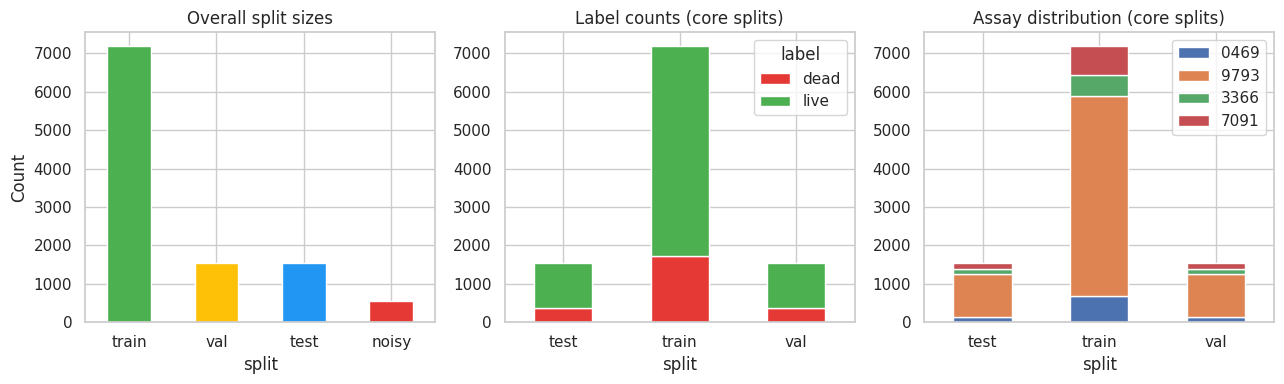


Global class weights for weighted loss (from train split):
  live: 0.658
  dead: 2.086


In [11]:
split_meta = split.merge(df[["sample_id", "label", "assay_id", "exp_id", "r_fov"]], on="sample_id")

# no sample appears in more than one split
assert split_meta["sample_id"].nunique() == len(split_meta), "Duplicate sample_ids!"
# every row in df is accounted for
assert len(split_meta) == len(df), f"Missing rows: {len(df) - len(split_meta)}"
print("No leakage: all sample_ids unique and all rows accounted for.")

core_splits = ["train", "val", "test"]
core = split_meta[split_meta["split"].isin(core_splits)]

print("\nLabel ratio per split (natural imbalance preserved):")
label_ratio = core.groupby(["split", "label"]).size().unstack(fill_value=0)
label_ratio["pct_dead"] = (label_ratio["dead"] / label_ratio.sum(axis=1) * 100).round(1)
display(label_ratio)

print("\nAssay distribution across core splits:")
display(core.groupby(["split", "assay_id"]).size().unstack(fill_value=0))

print("\nr_fov distribution across core splits:")
display(core.groupby(["split", "r_fov"]).size().unstack(fill_value=0))

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
colors = {"train": "#4CAF50", "val": "#FFC107", "test": "#2196F3", "noisy": "#E53935"}
split_counts = split_meta["split"].value_counts().reindex(["train", "val", "test", "noisy"])
split_counts.plot(kind="bar", ax=axes[0], color=[colors[s] for s in split_counts.index])
axes[0].set_title("Overall split sizes")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].set_ylabel("Count")

label_by_split = core.groupby(["split", "label"]).size().unstack(fill_value=0)
label_by_split.plot(kind="bar", stacked=True, ax=axes[1], color=["#E53935", "#4CAF50"])
axes[1].set_title("Label counts (core splits)")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)

assay_by_split = core.groupby(["split", "assay_id"]).size().unstack(fill_value=0)
assay_by_split.columns = [c.split("-")[-1] for c in assay_by_split.columns]
assay_by_split.plot(kind="bar", stacked=True, ax=axes[2])
axes[2].set_title("Assay distribution (core splits)")
axes[2].set_xticklabels(axes[2].get_xticklabels(), rotation=0)

plt.tight_layout()
plt.show()

# --- training class weights (global inverse frequency) ---
train_labels = core[core["split"] == "train"]["label"]
n_train = len(train_labels)
class_weights = {
    label: n_train / (2 * count)
    for label, count in train_labels.value_counts().items()
}
print(f"\nGlobal class weights for weighted loss (from train split):")
for label, w in class_weights.items():
    print(f"  {label}: {w:.3f}")

---

## Part 3: Model Training and Evaluation

**Model:** ResNet18 (ImageNet pretrained) with a 2-class head.

**Training choices:**
- Global weighted cross-entropy to handle class imbalance (live ~79%, dead ~21%)
- Grayscale replicated to 3 channels for transfer learning
- Train-set normalization (accounts for batch brightness differences)
- Augmentation: flips, rotation, brightness/contrast jitter
- Best checkpoint selected by validation macro F1

In [ ]:
!python train.py --epochs 15 --output-dir checkpoints

In [ ]:
import json
from pathlib import Path

history = json.loads(Path("checkpoints/history.json").read_text())
hist_df = pd.DataFrame(history)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label="train")
axes[0].plot(hist_df["epoch"], hist_df["val_loss"], label="val")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Training and validation loss")
axes[0].legend()

axes[1].plot(hist_df["epoch"], hist_df["val_f1"], label="val F1")
axes[1].plot(hist_df["epoch"], hist_df["val_balanced_acc"], label="val balanced acc")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Score")
axes[1].set_title("Validation metrics")
axes[1].legend()

plt.tight_layout()
plt.show()
hist_df.tail()

In [ ]:
!python evaluate.py --checkpoint checkpoints/best.pt --split test

In [ ]:
results = json.loads(Path("checkpoints/eval_results.json").read_text())
cm = np.array(results["overall"]["confusion_matrix"])

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["pred live", "pred dead"],
    yticklabels=["true live", "true dead"],
    ax=ax,
)
ax.set_title("Test set confusion matrix")
plt.tight_layout()
plt.show()

print("Overall test metrics:")
for k, v in results["overall"].items():
    if k != "confusion_matrix":
        print(f"  {k}: {v:.4f}")

### Training notes

- Class imbalance is handled via weighted cross-entropy, not by balancing the splits.
- Val/test keep the natural live/dead ratio; F1 and balanced accuracy are the primary metrics.
- Per-assay metrics (printed by `evaluate.py`) help detect batch-specific failure modes.
- Part 4 will add error analysis on misclassified examples.